# 🎵 Music Genre Classification - Version 6 (Final)

## 🎯 Goals
1. **Final Stable Pipeline**: Combine best practices from V2-V4, avoiding V5's pitfalls.
2. **Robust A-Team Models**: XGBoost, LightGBM, CatBoost (and optional RandomForest).
3. **Safe Ensembling**: Grid-search optimized Soft Voting & Simple Stacking.
4. **Target Score**: > 0.55555 (Beat V3).

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json

# Add src to path
sys.path.append(os.path.abspath("src"))

from preprocess.feature.feature import Feature
from model.LightGBM import ModelLightGBM
from model.XGBoost import ModelXGBoost
from model.Catboost import ModelCatboost
from model.Random_Forest import ModelRandomForest
from ensemble.ensemble import Ensemble
from evaluation.Evaluation import Evaluation
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# Set random seed
SEED = 42
np.random.seed(SEED)

## 1. Load Data & Preprocessing (V3 Style)
We reuse the robust preprocessing from V3: Median Imputation, Log Transform for skewed features, StandardScaler, and Correlation Removal.

In [2]:
DATA_DIR = "data"
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Encode Target
le = LabelEncoder()
train_df['Class_Encoded'] = le.fit_transform(train_df['Class'])
target_col = 'Class_Encoded'
classes = le.classes_
print(f"Classes: {classes}")

# Combine for preprocessing
train_df['is_train'] = 1
test_df['is_train'] = 0
full_df = pd.concat([train_df.drop(columns=['Class', 'Class_Encoded']), test_df], axis=0).reset_index(drop=True)

# Drop ID and Name columns
drop_cols = ['Id', 'Artist Name', 'Track Name']
full_df = full_df.drop(columns=drop_cols)

# Handle Missing Values (Median Imputation)
numeric_cols = full_df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    full_df[col] = full_df[col].fillna(full_df[col].median())

# Feature Engineering: Log Transform for Skewed Features
skewed_features = ['Popularity', 'loudness', 'duration_in min/ms', 'tempo']
for col in skewed_features:
    if col in full_df.columns:
        min_val = full_df[col].min()
        shift = abs(min_val) + 1 if min_val <= 0 else 0
        full_df[f'{col}_log'] = np.log1p(full_df[col] + shift)

# Scaling
scaler = StandardScaler()
scaled_cols = full_df.select_dtypes(include=np.number).columns.drop('is_train')
full_df[scaled_cols] = scaler.fit_transform(full_df[scaled_cols])

# Split back
X = full_df[full_df['is_train'] == 1].drop(columns=['is_train'])
X_test = full_df[full_df['is_train'] == 0].drop(columns=['is_train'])
y = train_df['Class_Encoded']

# Feature Selection (Reuse V3 logic - Remove High Correlation)
ft = Feature(pd.concat([X, y.rename(target_col)], axis=1), target_col=target_col, task='classification')
ft.correlation_analysis(threshold=0.95, show_report=False)
X_selected = ft.get_data().drop(columns=[target_col])
X_test_selected = X_test[X_selected.columns]

print(f"Selected Features: {X_selected.columns.tolist()}")

Train shape: (14396, 18)
Test shape: (3600, 17)
Classes: [ 0  1  2  3  4  5  6  7  8  9 10]


## 🔬 Correlation Analysis (threshold=0.95)

### ✅ Đã loại bỏ **2** features có correlation cao: ['loudness_log', 'tempo_log']

Selected Features: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'Popularity_log', 'duration_in min/ms_log']


## 2. Train A-Team Models (CV & OOF)
We use V4's tuned hyperparameters. We will train using StratifiedKFold (5 folds) and save OOF predictions.

🚀 Starting Training...

🔹 Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000781 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3017
[LightGBM] [Info] Number of data points in the train set: 11516, number of used features: 16
[LightGBM] [Info] Start training from score -3.360028
[LightGBM] [Info] Start training from score -2.572708
[LightGBM] [Info] Start training from score -2.648305
[LightGBM] [Info] Start training from score -3.802417
[LightGBM] [Info] Start training from score -3.838064
[LightGBM] [Info] Start training from score -2.521699
[LightGBM] [Info] Start training from score -1.939936
[LightGBM] [Info] Start training from score -3.443410
[LightGBM] [Info] Start training from score -2.272308
[LightGBM] [Info] Start training from score -1.964402
[LightGBM] [Info] Start training from score -1.290953
[LightGBM] [Warning] No further splits with positive gain, best gain: 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[451]	valid_0's multi_logloss: 1.18645



🔹 Evaluation Report for lightgbm (classification)
              precision    recall  f1-score   support

           0       0.68      0.79      0.73       100
           1       0.15      0.02      0.03       219
           2       0.50      0.42      0.46       203
           3       0.83      0.74      0.78        65
           4       0.57      0.68      0.62        62
           5       0.70      0.71      0.70       232
           6       0.41      0.33      0.36       414
           7       0.96      0.95      0.95        93
           8       0.62      0.57      0.59       296
           9       0.55      0.54      0.55       404
          10       0.47      0.66      0.55       792

    accuracy                           0.54      2880
   macro avg       0.59      0.58      0.58      2880
weighted avg       0.52      0.54      0.52      2880


 Tổng hợp metrics:
                   lightgbm
Accuracy           0.541319
Precision_macro    0.585064
Recall_macro       0.582165
F1_m

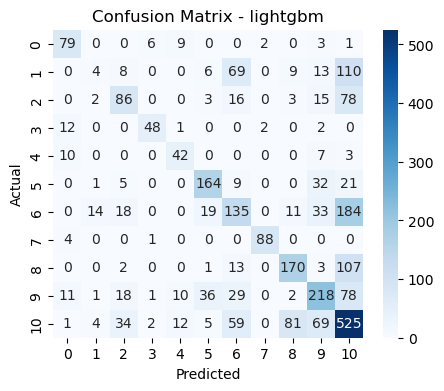

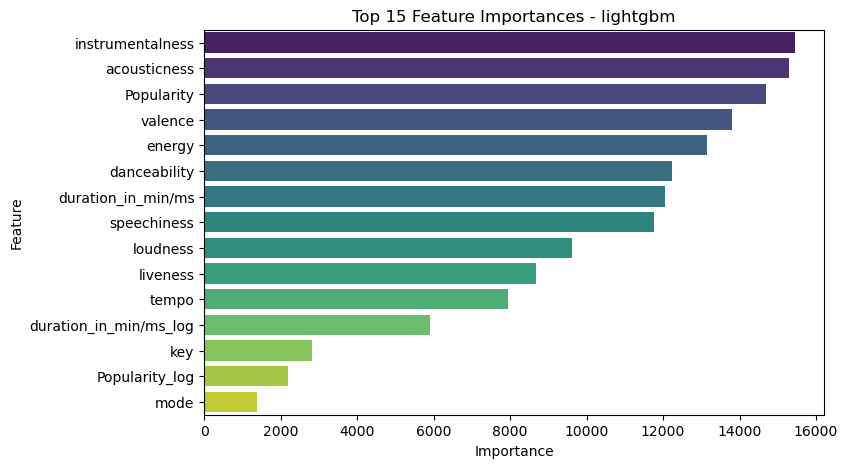

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000301 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3019
[LightGBM] [Info] Number of data points in the train set: 11517, number of used features: 16
[LightGBM] [Info] Start training from score -3.360115
[LightGBM] [Info] Start training from score -2.572795
[LightGBM] [Info] Start training from score -2.648391
[LightGBM] [Info] Start training from score -3.802503
[LightGBM] [Info] Start training from score -3.838151
[LightGBM] [Info] Start training from score -2.521786
[LightGBM] [Info] Start training from score -1.940023
[LightGBM] [Info] Start training from score -3.440783
[LightGBM] [Info] Start training from score -2.272395
[LightGBM] [Info] Start training from score -1.964489
[LightGBM] [Info] Start training from score -1.291039
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f


🔹 Evaluation Report for lightgbm (classification)
              precision    recall  f1-score   support

           0       0.71      0.74      0.73       100
           1       0.38      0.03      0.05       219
           2       0.52      0.42      0.46       203
           3       0.79      0.69      0.74        65
           4       0.72      0.71      0.72        62
           5       0.65      0.76      0.70       232
           6       0.47      0.36      0.40       414
           7       0.95      0.93      0.94        92
           8       0.61      0.52      0.56       296
           9       0.54      0.55      0.55       404
          10       0.49      0.69      0.57       792

    accuracy                           0.55      2879
   macro avg       0.62      0.58      0.58      2879
weighted avg       0.54      0.55      0.53      2879


 Tổng hợp metrics:
                   lightgbm
Accuracy           0.552275
Precision_macro    0.618700
Recall_macro       0.582498
F1_m

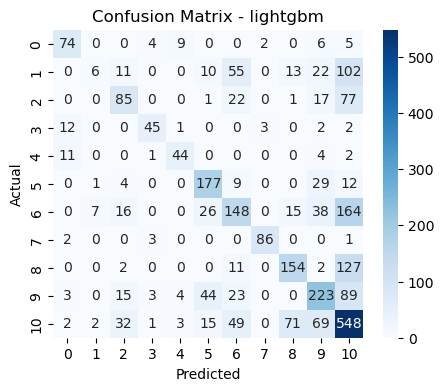

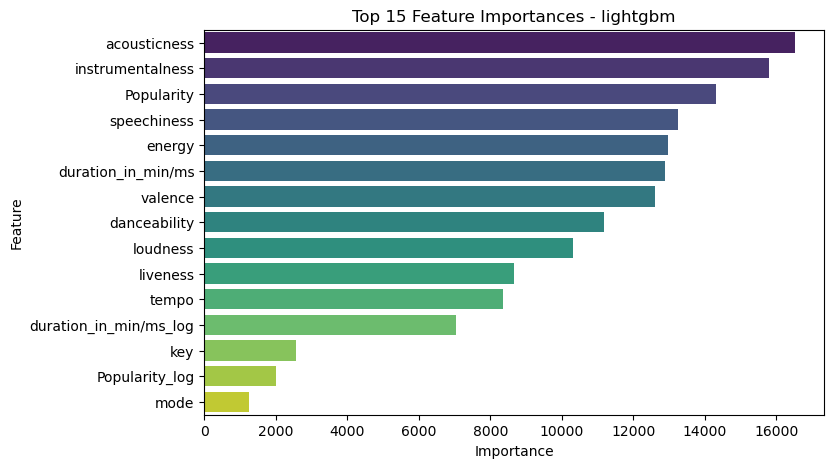

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000533 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3019
[LightGBM] [Info] Number of data points in the train set: 11517, number of used features: 16
[LightGBM] [Info] Start training from score -3.360115
[LightGBM] [Info] Start training from score -2.573933
[LightGBM] [Info] Start training from score -2.649619
[LightGBM] [Info] Start training from score -3.798620
[LightGBM] [Info] Start training from score -3.838151
[LightGBM] [Info] Start training from score -2.520705
[LightGBM] [Info] Start training from score -1.940023
[LightGBM] [Info] Start training from score -3.440783
[LightGBM] [Info] Start training from score -2.273238
[LightGBM] [Info] Start training from score -1.964489
[LightGBM] [Info] Start training from score -1.290724
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f


🔹 Evaluation Report for lightgbm (classification)
              precision    recall  f1-score   support

           0       0.68      0.75      0.71       100
           1       0.22      0.02      0.04       220
           2       0.53      0.42      0.47       204
           3       0.84      0.75      0.79        64
           4       0.65      0.74      0.69        62
           5       0.73      0.75      0.74       231
           6       0.41      0.33      0.37       414
           7       0.93      0.93      0.93        92
           8       0.64      0.56      0.59       297
           9       0.56      0.55      0.56       404
          10       0.48      0.68      0.56       791

    accuracy                           0.55      2879
   macro avg       0.61      0.59      0.59      2879
weighted avg       0.53      0.55      0.53      2879


 Tổng hợp metrics:
                   lightgbm
Accuracy           0.550538
Precision_macro    0.605571
Recall_macro       0.590461
F1_m

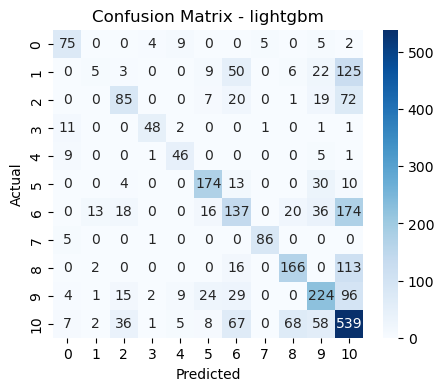

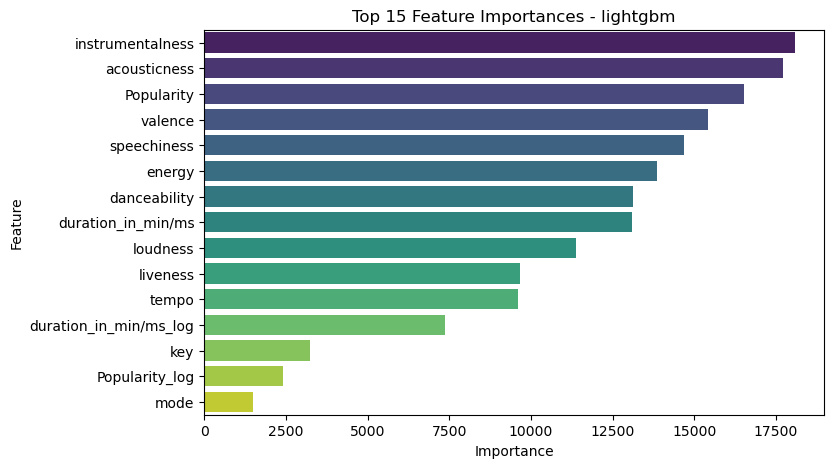

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000286 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3019
[LightGBM] [Info] Number of data points in the train set: 11517, number of used features: 16
[LightGBM] [Info] Start training from score -3.360115
[LightGBM] [Info] Start training from score -2.573933
[LightGBM] [Info] Start training from score -2.649619
[LightGBM] [Info] Start training from score -3.798620
[LightGBM] [Info] Start training from score -3.838151
[LightGBM] [Info] Start training from score -2.520705
[LightGBM] [Info] Start training from score -1.939419
[LightGBM] [Info] Start training from score -3.440783
[LightGBM] [Info] Start training from score -2.273238
[LightGBM] [Info] Start training from score -1.964489
[LightGBM] [Info] Start training from score -1.291039
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f


🔹 Evaluation Report for lightgbm (classification)
              precision    recall  f1-score   support

           0       0.68      0.82      0.75       100
           1       0.20      0.01      0.03       220
           2       0.49      0.38      0.43       204
           3       0.88      0.72      0.79        64
           4       0.65      0.58      0.62        62
           5       0.70      0.70      0.70       231
           6       0.42      0.33      0.37       413
           7       0.90      0.91      0.91        92
           8       0.67      0.56      0.61       297
           9       0.55      0.58      0.57       404
          10       0.48      0.70      0.56       792

    accuracy                           0.55      2879
   macro avg       0.60      0.57      0.58      2879
weighted avg       0.53      0.55      0.53      2879


 Tổng hợp metrics:
                   lightgbm
Accuracy           0.548454
Precision_macro    0.603375
Recall_macro       0.572279
F1_m

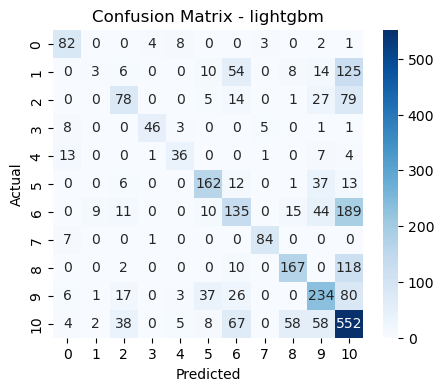

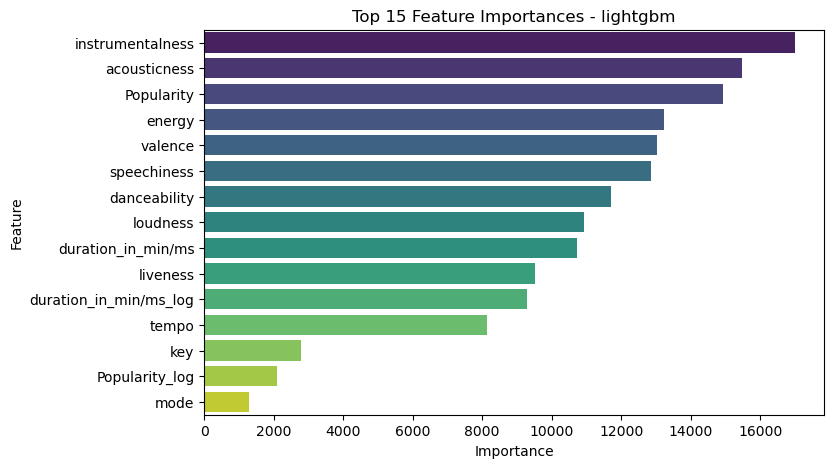

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000447 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3021
[LightGBM] [Info] Number of data points in the train set: 11517, number of used features: 16
[LightGBM] [Info] Start training from score -3.360115
[LightGBM] [Info] Start training from score -2.573933
[LightGBM] [Info] Start training from score -2.649619
[LightGBM] [Info] Start training from score -3.798620
[LightGBM] [Info] Start training from score -3.838151
[LightGBM] [Info] Start training from score -2.520705
[LightGBM] [Info] Start training from score -1.940023
[LightGBM] [Info] Start training from score -3.440783
[LightGBM] [Info] Start training from score -2.273238
[LightGBM] [Info] Start training from score -1.963870
[LightGBM] [Info] Start training from score -1.291039
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[509]	valid_0's multi_logloss: 1.20818



🔹 Evaluation Report for lightgbm (classification)
              precision    recall  f1-score   support

           0       0.69      0.81      0.75       100
           1       0.17      0.01      0.03       220
           2       0.59      0.44      0.50       204
           3       0.83      0.86      0.85        64
           4       0.69      0.69      0.69        62
           5       0.71      0.72      0.71       231
           6       0.40      0.30      0.34       414
           7       0.99      0.95      0.97        92
           8       0.56      0.49      0.52       297
           9       0.52      0.51      0.52       403
          10       0.46      0.68      0.55       792

    accuracy                           0.53      2879
   macro avg       0.60      0.59      0.58      2879
weighted avg       0.51      0.53      0.51      2879


 Tổng hợp metrics:
                   lightgbm
Accuracy           0.534908
Precision_macro    0.600581
Recall_macro       0.587711
F1_m

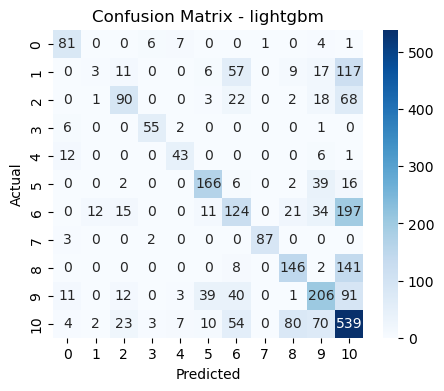

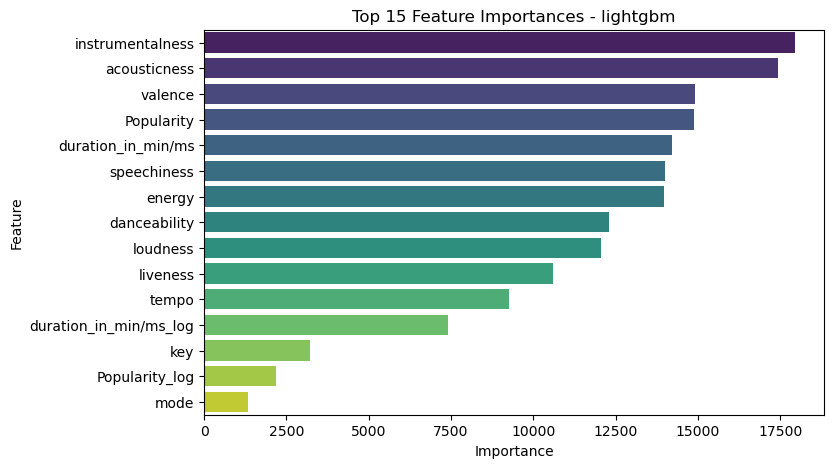

✅ LightGBM Average CV F1: 0.58103 | OOF F1: 0.58108


💾 Model saved to: experiments/Music_V6/models\lightgbm_best.pkl

🔹 Training XGBoost...



🔹 Evaluation Report for xgboost (classification)
              precision    recall  f1-score   support

           0       0.72      0.84      0.77       100
           1       0.11      0.03      0.04       219
           2       0.50      0.45      0.48       203
           3       0.83      0.77      0.80        65
           4       0.61      0.73      0.66        62
           5       0.71      0.69      0.70       232
           6       0.39      0.31      0.34       414
           7       0.96      0.95      0.95        93
           8       0.60      0.57      0.58       296
           9       0.54      0.53      0.54       404
          10       0.48      0.64      0.55       792

    accuracy                           0.54      2880
   macro avg       0.59      0.59      0.58      2880
weighted avg       0.51      0.54      0.52      2880


 Tổng hợp metrics:
                    xgboost
Accuracy           0.536806
Precision_macro    0.585365
Recall_macro       0.591888
F1_ma

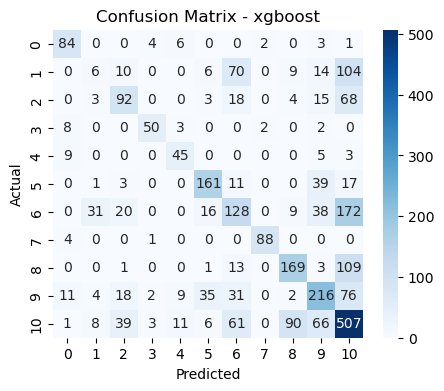

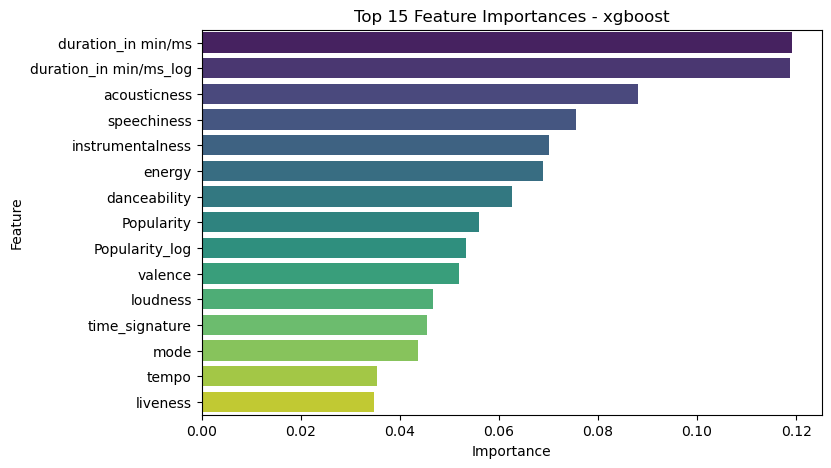


🔹 Evaluation Report for xgboost (classification)
              precision    recall  f1-score   support

           0       0.71      0.68      0.69       100
           1       0.15      0.03      0.05       219
           2       0.54      0.44      0.48       203
           3       0.79      0.69      0.74        65
           4       0.70      0.73      0.71        62
           5       0.66      0.73      0.69       232
           6       0.42      0.34      0.38       414
           7       0.95      0.93      0.94        92
           8       0.61      0.51      0.55       296
           9       0.55      0.56      0.55       404
          10       0.48      0.67      0.56       792

    accuracy                           0.54      2879
   macro avg       0.60      0.57      0.58      2879
weighted avg       0.52      0.54      0.52      2879


 Tổng hợp metrics:
                    xgboost
Accuracy           0.541507
Precision_macro    0.595194
Recall_macro       0.573666
F1_ma

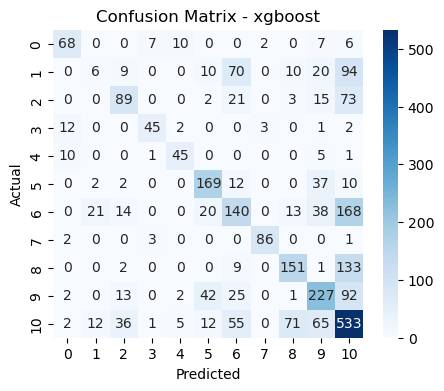

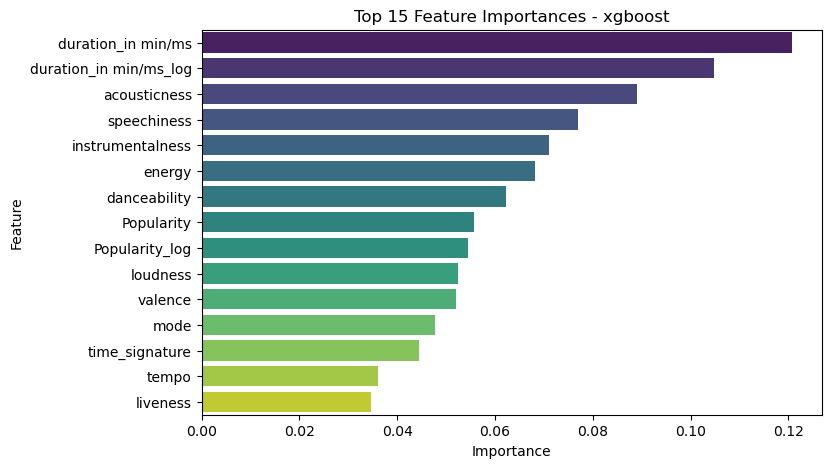


🔹 Evaluation Report for xgboost (classification)
              precision    recall  f1-score   support

           0       0.68      0.75      0.71       100
           1       0.13      0.03      0.05       220
           2       0.54      0.43      0.48       204
           3       0.81      0.75      0.78        64
           4       0.66      0.69      0.68        62
           5       0.75      0.75      0.75       231
           6       0.39      0.33      0.36       414
           7       0.92      0.93      0.93        92
           8       0.65      0.58      0.61       297
           9       0.57      0.55      0.56       404
          10       0.48      0.67      0.56       791

    accuracy                           0.55      2879
   macro avg       0.60      0.59      0.59      2879
weighted avg       0.53      0.55      0.53      2879


 Tổng hợp metrics:
                    xgboost
Accuracy           0.548802
Precision_macro    0.598744
Recall_macro       0.588179
F1_ma

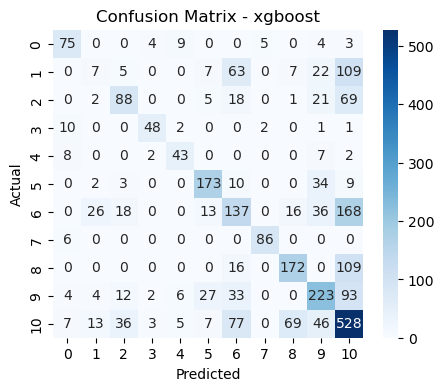

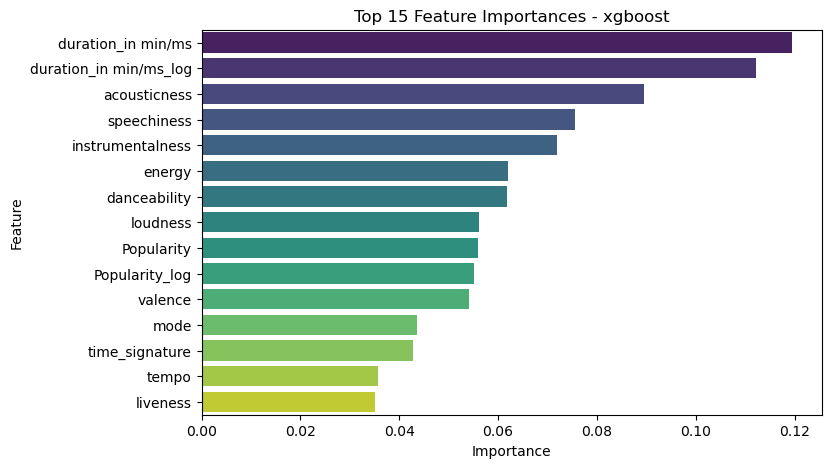


🔹 Evaluation Report for xgboost (classification)
              precision    recall  f1-score   support

           0       0.69      0.87      0.77       100
           1       0.10      0.01      0.02       220
           2       0.49      0.41      0.44       204
           3       0.88      0.72      0.79        64
           4       0.73      0.60      0.65        62
           5       0.70      0.70      0.70       231
           6       0.41      0.33      0.37       413
           7       0.92      0.90      0.91        92
           8       0.66      0.54      0.59       297
           9       0.57      0.58      0.57       404
          10       0.47      0.67      0.55       792

    accuracy                           0.54      2879
   macro avg       0.60      0.57      0.58      2879
weighted avg       0.52      0.54      0.52      2879


 Tổng hợp metrics:
                    xgboost
Accuracy           0.541855
Precision_macro    0.601074
Recall_macro       0.574877
F1_ma

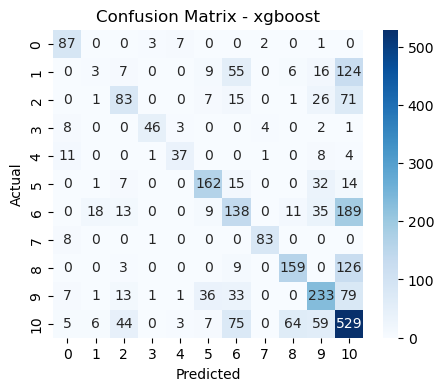

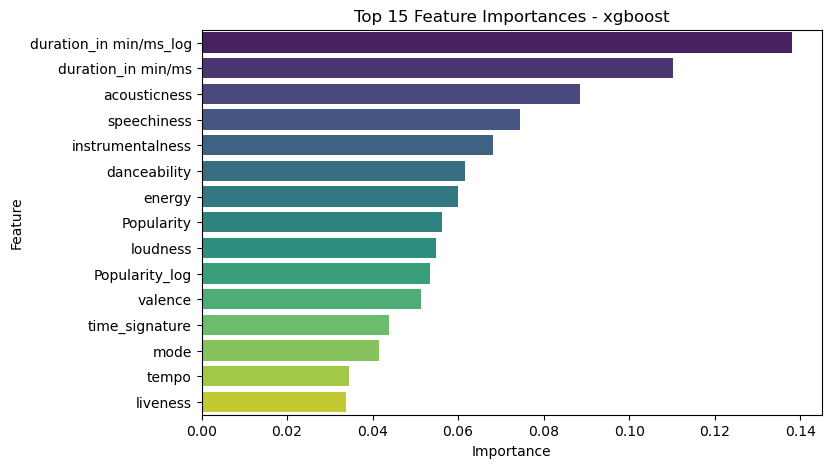


🔹 Evaluation Report for xgboost (classification)
              precision    recall  f1-score   support

           0       0.71      0.80      0.75       100
           1       0.09      0.02      0.03       220
           2       0.59      0.49      0.54       204
           3       0.82      0.86      0.84        64
           4       0.74      0.68      0.71        62
           5       0.72      0.71      0.71       231
           6       0.38      0.30      0.33       414
           7       0.98      0.93      0.96        92
           8       0.58      0.49      0.53       297
           9       0.54      0.53      0.53       403
          10       0.47      0.67      0.55       792

    accuracy                           0.54      2879
   macro avg       0.60      0.59      0.59      2879
weighted avg       0.51      0.54      0.52      2879


 Tổng hợp metrics:
                    xgboost
Accuracy           0.536297
Precision_macro    0.600813
Recall_macro       0.588291
F1_ma

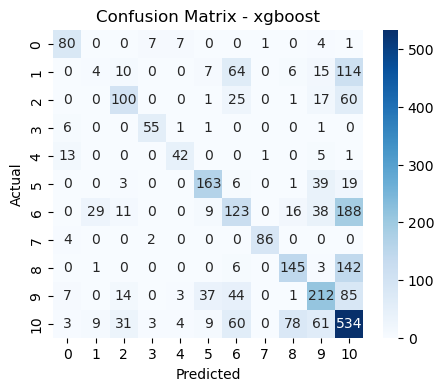

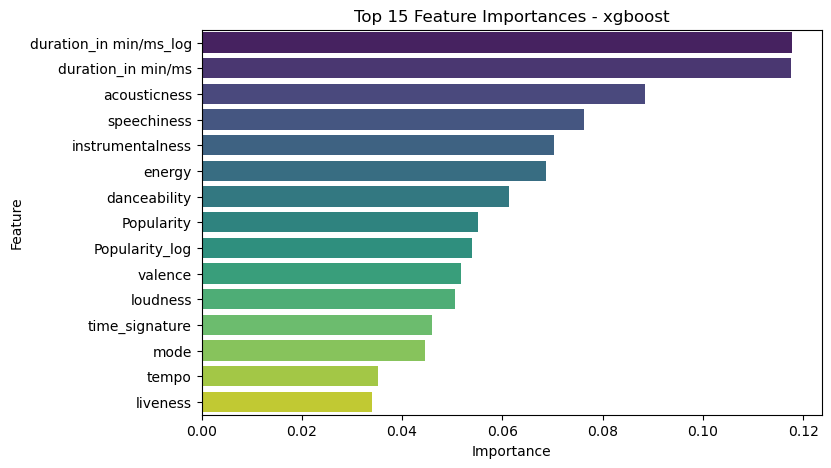

✅ XGBoost Average CV F1: 0.58359 | OOF F1: 0.58381


💾 Model saved to: experiments/Music_V6/models\xgboost_best.pkl

🔹 Training CatBoost...
0:	learn: 2.3502794	test: 2.3515226	best: 2.3515226 (0)	total: 125ms	remaining: 1m 22s


100:	learn: 1.3565276	test: 1.3856979	best: 1.3856979 (100)	total: 1.78s	remaining: 9.87s


200:	learn: 1.2030432	test: 1.2680912	best: 1.2680912 (200)	total: 3.36s	remaining: 7.66s


300:	learn: 1.1216054	test: 1.2239056	best: 1.2239056 (300)	total: 5.16s	remaining: 6.15s


400:	learn: 1.0604811	test: 1.2028036	best: 1.2028036 (400)	total: 6.9s	remaining: 4.46s


500:	learn: 1.0095483	test: 1.1900005	best: 1.1900005 (500)	total: 8.43s	remaining: 2.67s


600:	learn: 0.9647476	test: 1.1809246	best: 1.1809246 (600)	total: 9.95s	remaining: 976ms


659:	learn: 0.9409586	test: 1.1780930	best: 1.1780930 (659)	total: 10.8s	remaining: 0us

bestTest = 1.178092975
bestIteration = 659


🔹 Evaluation Report for catboost (classification)
              precision    recall  f1-score   support

           0       0.69      0.80      0.74       100
           1       0.17      0.01      0.02       219
           2       0.49      0.42      0.45       203
           3       0.82      0.69      0.75        65
           4       0.61      0.71      0.66        62
           5       0.72      0.71      0.71       232
           6       0.43      0.34      0.38       414
           7       0.96      0.95      0.95        93
           8       0.62      0.57      0.59       296
           9       0.52      0.55      0.53       404
          10       0.49      0.68      0.57       792

    accuracy                           0.55      2880
   macro avg       0.59      0.58      0.58      2880
weighted avg       0.52      0.55      0.52      2880


 T

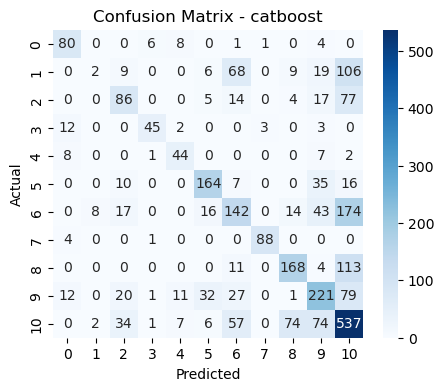

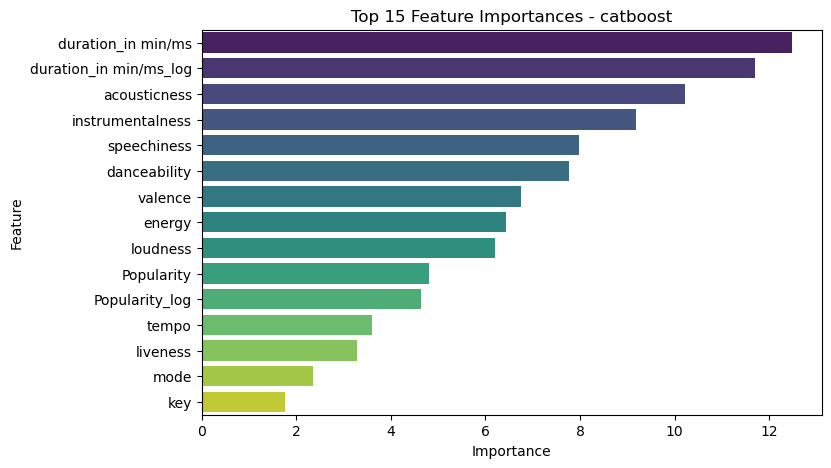

0:	learn: 2.3496038	test: 2.3511969	best: 2.3511969 (0)	total: 15.9ms	remaining: 10.4s


100:	learn: 1.3535839	test: 1.3953595	best: 1.3953595 (100)	total: 1.62s	remaining: 8.98s


200:	learn: 1.2010235	test: 1.2811983	best: 1.2811983 (200)	total: 3.2s	remaining: 7.3s


300:	learn: 1.1196824	test: 1.2376165	best: 1.2376165 (300)	total: 4.73s	remaining: 5.64s


400:	learn: 1.0612928	test: 1.2163374	best: 1.2163374 (400)	total: 6.29s	remaining: 4.07s


500:	learn: 1.0112425	test: 1.2015863	best: 1.2015863 (500)	total: 7.8s	remaining: 2.48s


600:	learn: 0.9662209	test: 1.1907810	best: 1.1907810 (600)	total: 9.66s	remaining: 948ms


659:	learn: 0.9423708	test: 1.1876948	best: 1.1876549 (658)	total: 10.6s	remaining: 0us

bestTest = 1.187654916
bestIteration = 658

Shrink model to first 659 iterations.

🔹 Evaluation Report for catboost (classification)
              precision    recall  f1-score   support

           0       0.66      0.68      0.67       100
           1       0.00      0.00      0.00       219
           2       0.51      0.42      0.46       203
           3       0.82      0.75      0.78        65
           4       0.67      0.63      0.65        62
           5       0.65      0.72      0.68       232
           6       0.47      0.34      0.40       414
           7       0.92      0.93      0.93        92
           8       0.61      0.54      0.57       296
           9       0.53      0.58      0.56       404
          10       0.49      0.70      0.58       792

    accuracy                           0.55      2879
   macro avg       0.58      0.57      0.57      2879
weighted avg       0

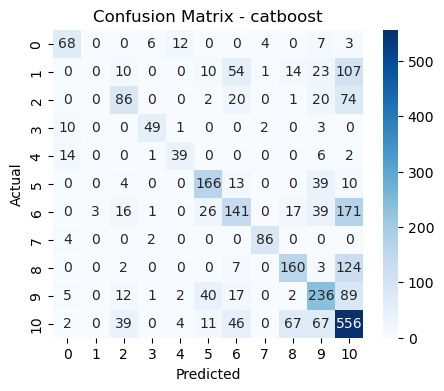

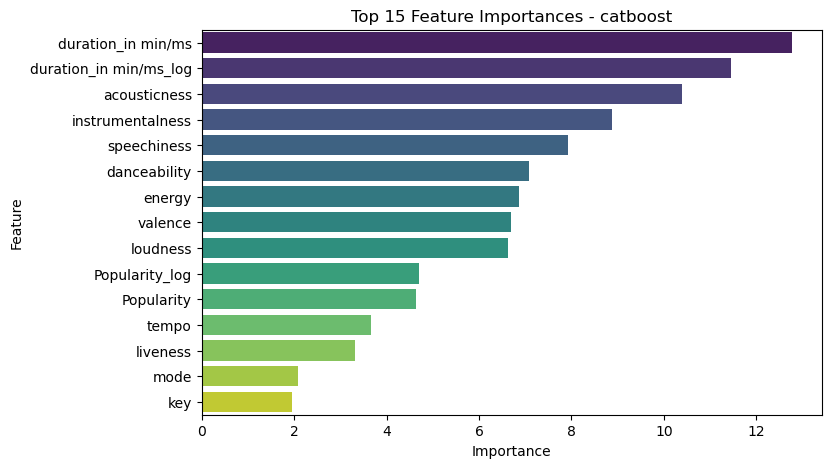

0:	learn: 2.3495919	test: 2.3517605	best: 2.3517605 (0)	total: 15.1ms	remaining: 9.96s


100:	learn: 1.3535774	test: 1.3910358	best: 1.3910358 (100)	total: 1.54s	remaining: 8.51s


200:	learn: 1.2028590	test: 1.2759636	best: 1.2759636 (200)	total: 3.09s	remaining: 7.06s


300:	learn: 1.1236635	test: 1.2319719	best: 1.2319719 (300)	total: 4.63s	remaining: 5.52s


400:	learn: 1.0643520	test: 1.2095995	best: 1.2095995 (400)	total: 6.13s	remaining: 3.96s


500:	learn: 1.0131845	test: 1.1953022	best: 1.1953022 (500)	total: 7.62s	remaining: 2.42s


600:	learn: 0.9688988	test: 1.1869730	best: 1.1869730 (600)	total: 9.14s	remaining: 898ms


659:	learn: 0.9440273	test: 1.1846746	best: 1.1846746 (659)	total: 10s	remaining: 0us

bestTest = 1.184674587
bestIteration = 659


🔹 Evaluation Report for catboost (classification)
              precision    recall  f1-score   support

           0       0.65      0.75      0.69       100
           1       0.31      0.02      0.03       220
           2       0.53      0.43      0.47       204
           3       0.75      0.64      0.69        64
           4       0.58      0.61      0.59        62
           5       0.73      0.75      0.74       231
           6       0.42      0.33      0.37       414
           7       0.92      0.93      0.93        92
           8       0.62      0.55      0.59       297
           9       0.56      0.57      0.57       404
          10       0.48      0.69      0.57       791

    accuracy                           0.55      2879
   macro avg       0.60      0.57      0.57      2879
weighted avg       0.54      0.55      0.53      2879


 Tổn

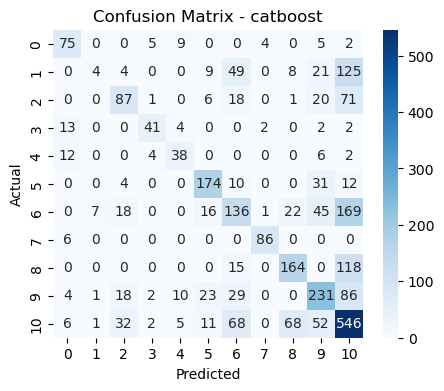

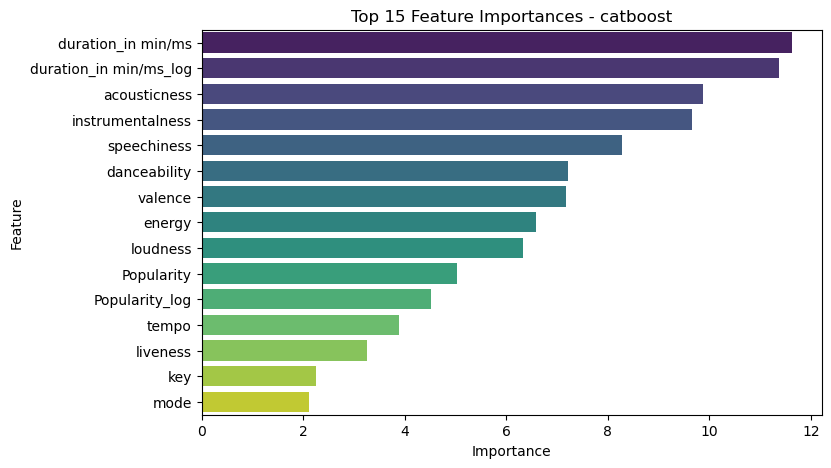

0:	learn: 2.3503926	test: 2.3500501	best: 2.3500501 (0)	total: 14.5ms	remaining: 9.57s


100:	learn: 1.3517105	test: 1.3879938	best: 1.3879938 (100)	total: 1.53s	remaining: 8.46s


200:	learn: 1.2004196	test: 1.2752885	best: 1.2752885 (200)	total: 3.04s	remaining: 6.94s


300:	learn: 1.1221450	test: 1.2347107	best: 1.2347107 (300)	total: 4.58s	remaining: 5.46s


400:	learn: 1.0625398	test: 1.2132628	best: 1.2132628 (400)	total: 6.08s	remaining: 3.93s


500:	learn: 1.0125385	test: 1.1983249	best: 1.1983249 (500)	total: 7.63s	remaining: 2.42s


600:	learn: 0.9668243	test: 1.1896778	best: 1.1896778 (600)	total: 9.12s	remaining: 895ms


659:	learn: 0.9415685	test: 1.1859739	best: 1.1859739 (659)	total: 10.3s	remaining: 0us

bestTest = 1.185973854
bestIteration = 659


🔹 Evaluation Report for catboost (classification)
              precision    recall  f1-score   support

           0       0.68      0.82      0.75       100
           1       0.12      0.00      0.01       220
           2       0.49      0.38      0.43       204
           3       0.76      0.73      0.75        64
           4       0.72      0.63      0.67        62
           5       0.70      0.72      0.71       231
           6       0.43      0.33      0.37       413
           7       0.89      0.92      0.91        92
           8       0.68      0.55      0.60       297
           9       0.55      0.57      0.56       404
          10       0.48      0.70      0.57       792

    accuracy                           0.55      2879
   macro avg       0.59      0.58      0.58      2879
weighted avg       0.53      0.55      0.53      2879


 T

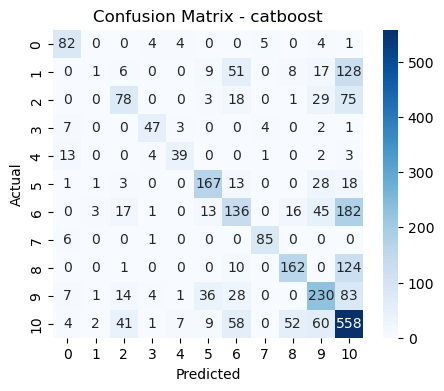

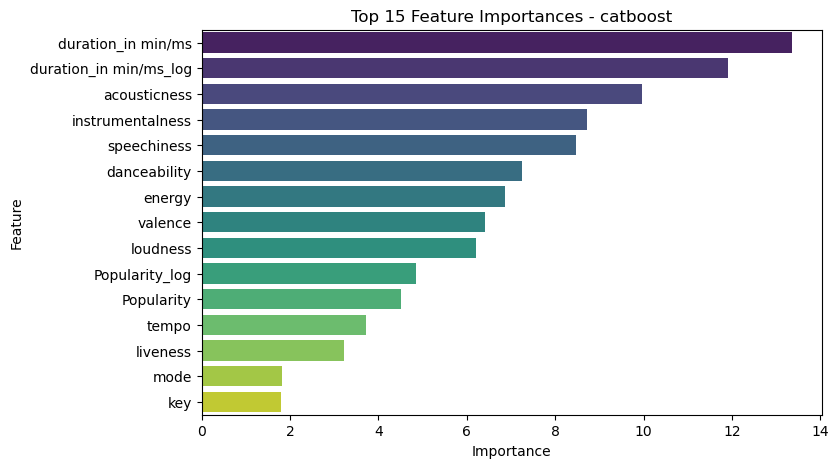

0:	learn: 2.3500027	test: 2.3513517	best: 2.3513517 (0)	total: 14.9ms	remaining: 9.82s


100:	learn: 1.3505620	test: 1.4051613	best: 1.4051613 (100)	total: 1.66s	remaining: 9.2s


200:	learn: 1.1979960	test: 1.2896969	best: 1.2896969 (200)	total: 3.17s	remaining: 7.24s


300:	learn: 1.1194293	test: 1.2473826	best: 1.2473826 (300)	total: 4.7s	remaining: 5.6s


400:	learn: 1.0591168	test: 1.2252945	best: 1.2252945 (400)	total: 6.2s	remaining: 4.01s


500:	learn: 1.0069199	test: 1.2108856	best: 1.2108856 (500)	total: 7.74s	remaining: 2.46s


600:	learn: 0.9599724	test: 1.2028690	best: 1.2028690 (600)	total: 9.24s	remaining: 907ms


659:	learn: 0.9347399	test: 1.1994496	best: 1.1994496 (659)	total: 10.1s	remaining: 0us

bestTest = 1.199449592
bestIteration = 659


🔹 Evaluation Report for catboost (classification)
              precision    recall  f1-score   support

           0       0.69      0.70      0.69       100
           1       0.33      0.02      0.03       220
           2       0.61      0.43      0.50       204
           3       0.79      0.81      0.80        64
           4       0.67      0.66      0.67        62
           5       0.68      0.70      0.69       231
           6       0.42      0.31      0.36       414
           7       0.93      0.97      0.95        92
           8       0.58      0.53      0.55       297
           9       0.51      0.53      0.52       403
          10       0.47      0.70      0.57       792

    accuracy                           0.54      2879
   macro avg       0.61      0.58      0.58      2879
weighted avg       0.53      0.54      0.52      2879


 T

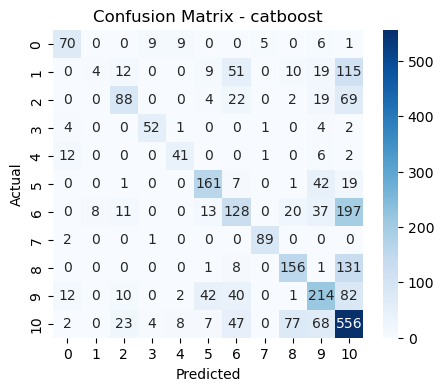

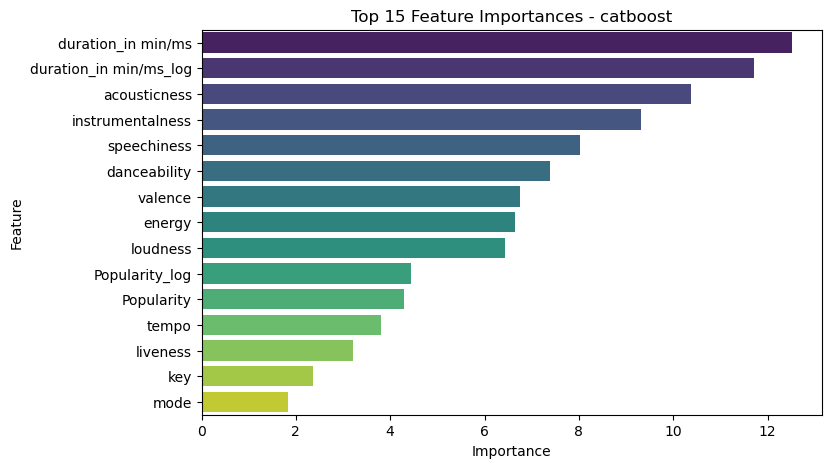

✅ CatBoost Average CV F1: 0.57354 | OOF F1: 0.57360

🔹 Training RandomForest...
🚀 Huấn luyện mô hình Random Forest...



🔹 Evaluation Report for random_forest (classification)
              precision    recall  f1-score   support

           0       0.67      0.86      0.75       100
           1       0.07      0.01      0.02       219
           2       0.55      0.32      0.40       203
           3       0.83      0.74      0.78        65
           4       0.66      0.71      0.68        62
           5       0.70      0.68      0.69       232
           6       0.40      0.31      0.35       414
           7       0.96      0.94      0.95        93
           8       0.61      0.51      0.55       296
           9       0.52      0.54      0.53       404
          10       0.46      0.68      0.55       792

    accuracy                           0.53      2880
   macro avg       0.58      0.57      0.57      2880
weighted avg       0.51      0.53      0.51      2880


 Tổng hợp metrics:
                   random_forest
Accuracy                0.531250
Precision_macro         0.584012
Recall_macro

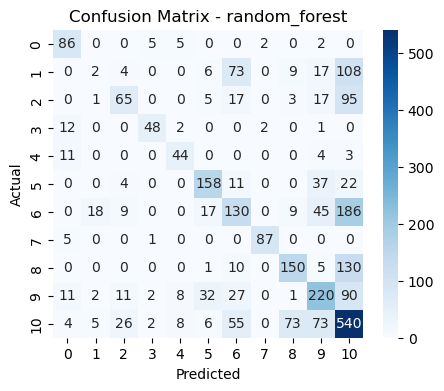

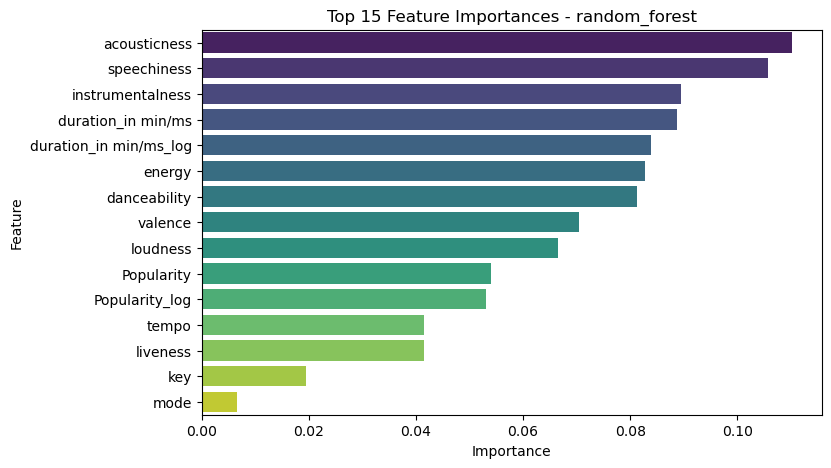

💾 Model đã được lưu tại: experiments/models\random_forest_best.pkl


🚀 Huấn luyện mô hình Random Forest...



🔹 Evaluation Report for random_forest (classification)
              precision    recall  f1-score   support

           0       0.67      0.71      0.69       100
           1       0.11      0.01      0.02       219
           2       0.57      0.31      0.40       203
           3       0.79      0.68      0.73        65
           4       0.70      0.63      0.66        62
           5       0.63      0.70      0.66       232
           6       0.42      0.31      0.36       414
           7       0.96      0.93      0.95        92
           8       0.61      0.45      0.52       296
           9       0.52      0.56      0.54       404
          10       0.46      0.71      0.56       792

    accuracy                           0.53      2879
   macro avg       0.58      0.55      0.55      2879
weighted avg       0.51      0.53      0.50      2879


 Tổng hợp metrics:
                   random_forest
Accuracy                0.527961
Precision_macro         0.584761
Recall_macro

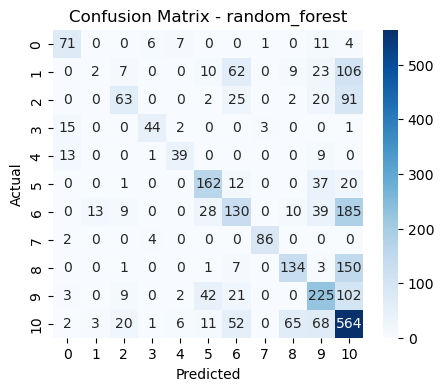

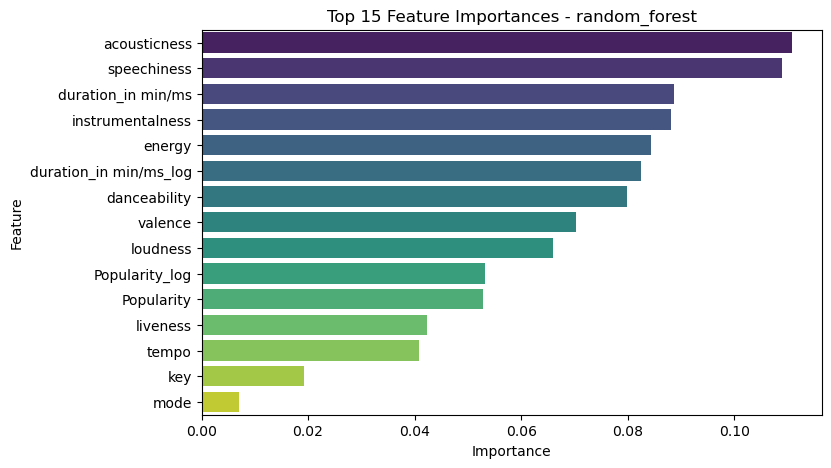

💾 Model đã được lưu tại: experiments/models\random_forest_best.pkl


🚀 Huấn luyện mô hình Random Forest...



🔹 Evaluation Report for random_forest (classification)
              precision    recall  f1-score   support

           0       0.67      0.80      0.73       100
           1       0.26      0.02      0.04       220
           2       0.57      0.29      0.39       204
           3       0.78      0.72      0.75        64
           4       0.59      0.68      0.63        62
           5       0.74      0.73      0.73       231
           6       0.40      0.32      0.36       414
           7       0.93      0.93      0.93        92
           8       0.65      0.51      0.57       297
           9       0.53      0.53      0.53       404
          10       0.45      0.70      0.55       791

    accuracy                           0.53      2879
   macro avg       0.60      0.57      0.56      2879
weighted avg       0.53      0.53      0.51      2879


 Tổng hợp metrics:
                   random_forest
Accuracy                0.534213
Precision_macro         0.598542
Recall_macro

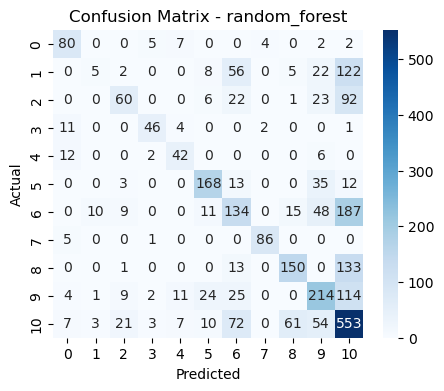

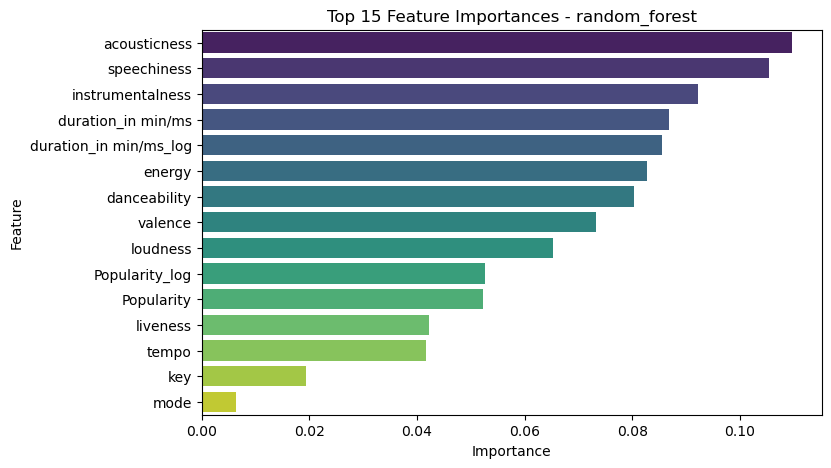

💾 Model đã được lưu tại: experiments/models\random_forest_best.pkl


🚀 Huấn luyện mô hình Random Forest...



🔹 Evaluation Report for random_forest (classification)
              precision    recall  f1-score   support

           0       0.69      0.87      0.77       100
           1       0.17      0.01      0.02       220
           2       0.53      0.32      0.40       204
           3       0.85      0.72      0.78        64
           4       0.62      0.52      0.56        62
           5       0.70      0.71      0.71       231
           6       0.40      0.31      0.35       413
           7       0.94      0.92      0.93        92
           8       0.70      0.53      0.60       297
           9       0.53      0.54      0.54       404
          10       0.45      0.71      0.55       792

    accuracy                           0.54      2879
   macro avg       0.60      0.56      0.56      2879
weighted avg       0.52      0.54      0.51      2879


 Tổng hợp metrics:
                   random_forest
Accuracy                0.535603
Precision_macro         0.598159
Recall_macro

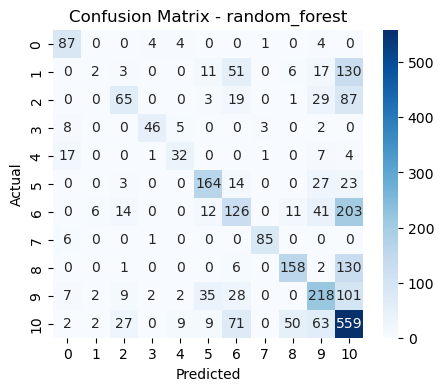

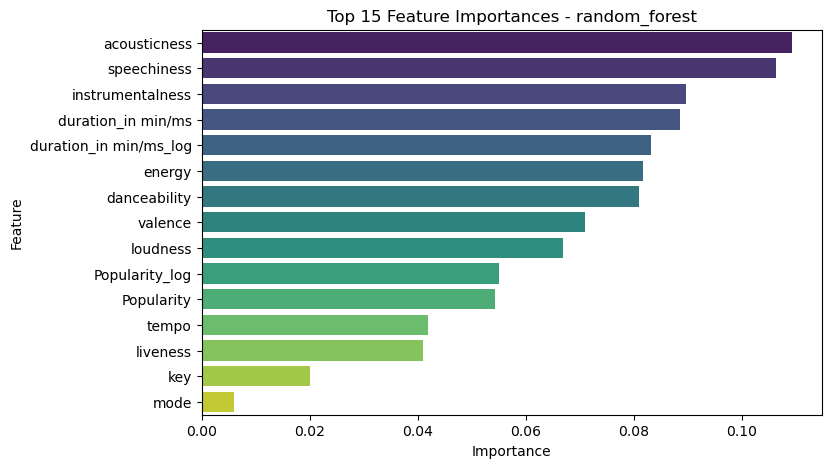

💾 Model đã được lưu tại: experiments/models\random_forest_best.pkl


🚀 Huấn luyện mô hình Random Forest...



🔹 Evaluation Report for random_forest (classification)
              precision    recall  f1-score   support

           0       0.66      0.77      0.71       100
           1       0.27      0.03      0.05       220
           2       0.62      0.32      0.42       204
           3       0.76      0.80      0.78        64
           4       0.69      0.65      0.67        62
           5       0.71      0.68      0.70       231
           6       0.36      0.26      0.30       414
           7       0.96      0.96      0.96        92
           8       0.60      0.47      0.53       297
           9       0.50      0.50      0.50       403
          10       0.45      0.72      0.55       792

    accuracy                           0.52      2879
   macro avg       0.60      0.56      0.56      2879
weighted avg       0.52      0.52      0.50      2879


 Tổng hợp metrics:
                   random_forest
Accuracy                0.522404
Precision_macro         0.598688
Recall_macro

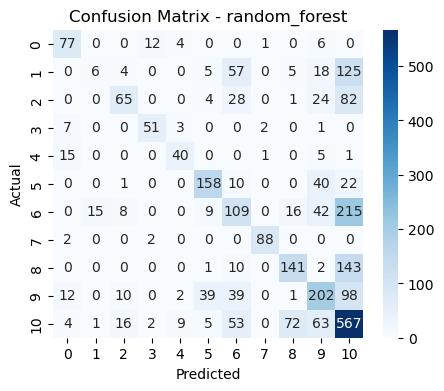

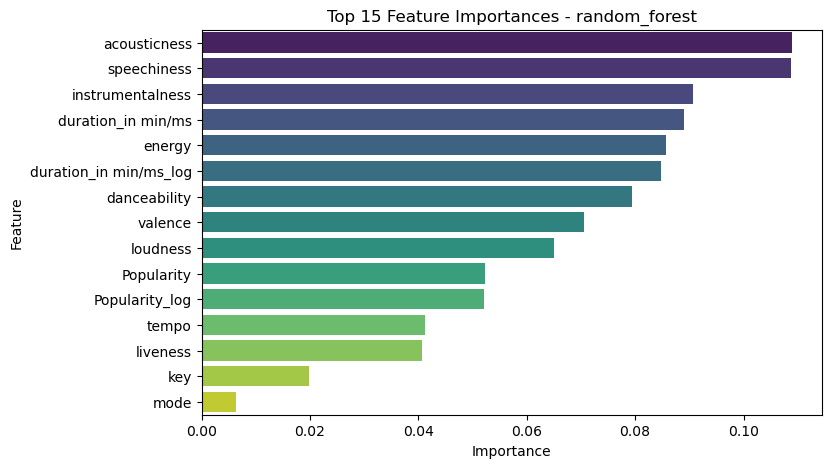

💾 Model đã được lưu tại: experiments/models\random_forest_best.pkl


✅ RandomForest Average CV F1: 0.56230 | OOF F1: 0.56250
💾 Model đã được lưu tại: experiments/Music_V6/models\random_forest_best.pkl


In [3]:
# Define V4 Best Params
params_lgbm = {'n_estimators': 1320, 'learning_rate': 0.0109, 'max_depth': 6, 'num_leaves': 31, 'subsample': 0.727, 'colsample_bytree': 0.865, 'min_child_samples': 20}
params_xgb = {'n_estimators': 1320, 'learning_rate': 0.0109, 'max_depth': 6, 'subsample': 0.727, 'colsample_bytree': 0.865, 'min_child_weight': 1, 'gamma': 2e-7}
params_cat = {'depth': 6, 'learning_rate': 0.0215, 'iterations': 660, 'l2_leaf_reg': 1.9e-8, 'subsample': 0.984, 'colsample_bylevel': 0.761, 'bootstrap_type': 'Bernoulli'}
params_rf = {'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_samples': 0.746}

# Initialize Models
models = {
    "LightGBM": ModelLightGBM(task="classification", params=params_lgbm, random_state=SEED),
    "XGBoost": ModelXGBoost(task="classification", params=params_xgb, random_state=SEED),
    "CatBoost": ModelCatboost(task="classification", params=params_cat, random_state=SEED),
    "RandomForest": ModelRandomForest(task="classification", params=params_rf, random_state=SEED)
}

# Storage for OOF and Test Preds
oof_preds = {}
test_preds = {}
model_scores = {}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("🚀 Starting Training...")

for name, model_wrapper in models.items():
    print(f"\n🔹 Training {name}...")
    
    # Create arrays
    oof_probs = np.zeros((X_selected.shape[0], len(classes)))
    test_probs_fold = np.zeros((X_test_selected.shape[0], len(classes)))
    
    f1_scores = []
    
    # Manual CV Loop to control everything
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected, y)):
        X_train_fold, y_train_fold = X_selected.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X_selected.iloc[val_idx], y.iloc[val_idx]
        
        # Train
        clf = model_wrapper.train(X_train=X_train_fold, y_train=y_train_fold, X_test=X_val_fold, y_test=y_val_fold)
        
        # Predict OOF
        val_probs = model_wrapper.predict_proba(X_val_fold)
        oof_probs[val_idx] = val_probs
        
        # Predict Test
        test_probs_fold += model_wrapper.predict_proba(X_test_selected) / kf.get_n_splits()
        
        # Score
        val_pred = np.argmax(val_probs, axis=1)
        score = f1_score(y_val_fold, val_pred, average='macro')
        f1_scores.append(score)
        # print(f"  Fold {fold+1} F1: {score:.4f}")
    
    # Store results
    oof_preds[name] = oof_probs
    test_preds[name] = test_probs_fold
    
    avg_f1 = np.mean(f1_scores)
    oof_f1 = f1_score(y, np.argmax(oof_probs, axis=1), average='macro')
    model_scores[name] = oof_f1
    
    print(f"✅ {name} Average CV F1: {avg_f1:.5f} | OOF F1: {oof_f1:.5f}")
    
    # Save model artifact (last fold model, or retrain full later)
    model_wrapper.save_model(folder="experiments/Music_V6/models")

## 3. Ensemble Strategy
### 3.1 Soft Voting with Grid Search
We search for optimal weights for the A-Team (XGB, LGBM, Cat) + optionally RF.

In [4]:
ensemble = Ensemble(models=[], task="classification", random_state=SEED)

# 1. Top 3 (XGB, LGBM, Cat)
print("\n🔎 Grid Search Weights for Top 3 (XGB, LGBM, Cat)...")
top3_oof = {k: oof_preds[k] for k in ["XGBoost", "LightGBM", "CatBoost"]}
best_weights_3 = ensemble.grid_search_weights(top3_oof, y, step=0.05)
print("Best Weights Top 3:", best_weights_3)

# 2. All 4 (XGB, LGBM, Cat, RF)
print("\n🔎 Grid Search Weights for All 4 (XGB, LGBM, Cat, RF)...")
best_weights_4 = ensemble.grid_search_weights(oof_preds, y, step=0.05)
print("Best Weights All 4:", best_weights_4)


🔎 Grid Search Weights for Top 3 (XGB, LGBM, Cat)...


✅ Best Grid Search F1: 0.58899
Best Weights Top 3: {'XGBoost': np.float64(0.25), 'LightGBM': np.float64(0.4), 'CatBoost': np.float64(0.35000000000000003)}

🔎 Grid Search Weights for All 4 (XGB, LGBM, Cat, RF)...


✅ Best Grid Search F1: 0.58899
Best Weights All 4: {'LightGBM': np.float64(0.4), 'XGBoost': np.float64(0.25), 'CatBoost': np.float64(0.35000000000000003), 'RandomForest': np.float64(0.0)}


### 3.2 Stacking
Train a Logistic Regression meta-model on OOF probabilities.

In [5]:
# Prepare Meta-Features
X_meta_train = np.hstack([oof_preds[name] for name in models.keys()])
X_meta_test = np.hstack([test_preds[name] for name in models.keys()])

print(f"Meta Train Shape: {X_meta_train.shape}")

# Train Meta Model (Logistic Regression)
meta_model = LogisticRegression(random_state=SEED, max_iter=1000)
meta_model.fit(X_meta_train, y)

# Evaluate Meta Model
meta_oof_pred = meta_model.predict(X_meta_train)
stacking_f1 = f1_score(y, meta_oof_pred, average='macro')
print(f"✅ Stacking OOF F1: {stacking_f1:.5f}")

Meta Train Shape: (14396, 44)


✅ Stacking OOF F1: 0.60173


## 4. Final Selection & Submission
Compare Single Best vs. Weighted Ensemble vs. Stacking.

In [6]:
# Compare Scores
scores = model_scores.copy()

# Calculate Voting Scores manually for comparison
def get_voting_score(weights_dict, oof_dict):
    final_prob = np.zeros_like(list(oof_dict.values())[0])
    for name, w in weights_dict.items():
        final_prob += w * oof_dict[name]
    return f1_score(y, np.argmax(final_prob, axis=1), average='macro')

scores['Voting_Top3'] = get_voting_score(best_weights_3, top3_oof)
scores['Voting_All4'] = get_voting_score(best_weights_4, oof_preds)
scores['Stacking'] = stacking_f1

print("\n🏆 Final Comparison:")
print(pd.Series(scores).sort_values(ascending=False))

# Select Best Strategy
best_strategy = max(scores, key=scores.get)
print(f"\n🌟 Best Strategy: {best_strategy}")

# Generate Submission
if "Voting" in best_strategy:
    weights = best_weights_3 if "Top3" in best_strategy else best_weights_4
    used_preds = top3_oof if "Top3" in best_strategy else oof_preds
    used_test = {k: test_preds[k] for k in used_preds.keys()}
    
    final_test_prob = np.zeros_like(list(used_test.values())[0])
    for name, w in weights.items():
        final_test_prob += w * used_test[name]
    final_pred = np.argmax(final_test_prob, axis=1)
    
elif best_strategy == "Stacking":
    final_pred = meta_model.predict(X_meta_test)
    
else: # Single Model
    final_pred = np.argmax(test_preds[best_strategy], axis=1)

# Decode Labels
final_labels = le.inverse_transform(final_pred)

# Create Submission DataFrame
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'Class': final_labels
})

# Save
os.makedirs("experiments/Music_V6", exist_ok=True)
sub_path = "experiments/Music_V6/submission_music_v6_final.csv"
submission.to_csv(sub_path, index=False)
print(f"\n💾 Submission saved to: {sub_path}")
print(submission.head())


🏆 Final Comparison:
Stacking        0.601730
Voting_Top3     0.588985
Voting_All4     0.588985
XGBoost         0.583815
LightGBM        0.581083
CatBoost        0.573596
RandomForest    0.562498
dtype: float64

🌟 Best Strategy: Stacking

💾 Submission saved to: experiments/Music_V6/submission_music_v6_final.csv
      Id  Class
0  14397      6
1  14398      6
2  14399      9
3  14400     10
4  14401      5
